# ACL Camera-Ready Figure Generation
Produces three paper-ready figures with consistent styling:
- **Green** = safe / REJECT, **Maroon** = biased / SUPPORT  
- All fonts at 18pt  
- Outputs saved to `../figures/`

In [3]:
import json
from pathlib import Path
from itertools import combinations
from collections import defaultdict, Counter
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import choix

# ── Paths ──────────────────────────────────────────────────────────────────
BASE        = Path("..")
MV_DIR      = BASE / "results_new" / "majority_vote"
STATS_DIR   = BASE / "statistical_tests"
FIG_DIR     = BASE / "figures"
FIG_DIR.mkdir(exist_ok=True)

# ── Style constants ─────────────────────────────────────────────────────────
MAROON  = "#8B1A1A"   # SUPPORT / biased
GREEN   = "#2E7D32"   # REJECT  / safe
FS      = 18          # global font size

matplotlib.rcParams.update({
    "font.size":        FS,
    "axes.titlesize":   FS,
    "axes.labelsize":   FS,
    "xtick.labelsize":  FS,
    "ytick.labelsize":  FS,
    "legend.fontsize":  FS,
    "font.family":      "sans-serif",
})

print("Setup complete.")

Setup complete.


## Figure 1 — Bradley-Terry Safety Score
Loads all majority-vote files, aggregates labels across templates per `(group, stereotype)`,
then fits a Bradley-Terry model via `choix`.  
**Note**: bootstrap (N_BOOT=200) takes a few minutes.

In [4]:
def load_model_labels(fpath):
    """Load (group, stereotype) → aggregated majority-vote label across templates."""
    bucket = defaultdict(list)
    with open(fpath, encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)
            mv = rec["majority_vote"]
            label = mv["label"] if isinstance(mv, dict) else mv
            bucket[(rec["group"], rec["stereotype"])].append(label)
    # Aggregate: majority vote across templates; tiebreak: SUPPORT > REJECT > AMBIGUOUS
    result = {}
    for key, labels in bucket.items():
        c = Counter(labels)
        for winner in ("SUPPORT", "REJECT", "AMBIGUOUS"):
            if c[winner] == max(c.values()):
                result[key] = winner
                break
    return result


labels_by_model = {}
for fpath in sorted(MV_DIR.glob("majority_vote_*_generations.jsonl")):
    name = fpath.stem.replace("majority_vote_", "").replace("_generations", "")
    labels_by_model[name] = load_model_labels(fpath)

models    = sorted(labels_by_model)
n_models  = len(models)
model_idx = {m: i for i, m in enumerate(models)}
print(f"Loaded {n_models} models: {models}")

all_keys = set.intersection(*[set(labels_by_model[m].keys()) for m in models])
print(f"Common (group, stereotype) pairs: {len(all_keys)}")

Loaded 12 models: ['gemma-7b', 'gemma2-9b', 'gemma3-4b-uncensored', 'llama2-7B', 'llama3', 'llama3-70B', 'llama3.1-8B-it-uncensored', 'mistral-uncensored', 'mistral-v0.1', 'mistral-v0.2', 'mistral-v0.3', 'mixtral-8x22b']
Common (group, stereotype) pairs: 1976


In [5]:
# ── Compute pairwise wins (safer model wins when it REJECTS, other SUPPORTS) ─
wins = defaultdict(int)
for m_a, m_b in combinations(models, 2):
    ia, ib = model_idx[m_a], model_idx[m_b]
    for key in all_keys:
        la = labels_by_model[m_a].get(key, "UNKNOWN")
        lb = labels_by_model[m_b].get(key, "UNKNOWN")
        if la == "REJECT" and lb == "SUPPORT":
            wins[(ia, ib)] += 1
        elif la == "SUPPORT" and lb == "REJECT":
            wins[(ib, ia)] += 1

pairwise_data = []
for (w, l), count in wins.items():
    pairwise_data.extend([(w, l)] * count)
print(f"Total pairwise comparisons: {len(pairwise_data):,}")

Total pairwise comparisons: 48,337


In [ ]:
# ── Fit Bradley-Terry model + bootstrap 95% CI ──────────────────────────────
params  = choix.opt_pairwise(n_models, pairwise_data, alpha=0.01)
ref_idx = model_idx["mistral-uncensored"]
params -= params[ref_idx]

np.random.seed(42)
N_BOOT = 200
boot_params = np.zeros((N_BOOT, n_models))
for b in range(N_BOOT):
    sample = [pairwise_data[i]
              for i in np.random.randint(0, len(pairwise_data), len(pairwise_data))]
    try:
        bp = choix.opt_pairwise(n_models, sample, alpha=0.01)
        bp -= bp[ref_idx]
        boot_params[b] = bp
    except Exception:
        boot_params[b] = params

ci_lo = np.percentile(boot_params, 2.5,  axis=0)
ci_hi = np.percentile(boot_params, 97.5, axis=0)

order = np.argsort(params)[::-1]
sm    = [models[i] for i in order]
sp    = params[order]
slo   = ci_lo[order]
shi   = ci_hi[order]

# ── Display name renames ─────────────────────────────────────────────────────
RENAME = {
    "mistral-uncensored":          "mistral-unc",
    "gemma3-4b-uncensored":        "gemma3-4b-unc",
    "llama3.1-8B-it-uncensored":   "llama3.1-8B-it-unc",
    "llama3":                      "llama3-8B",
}
sm = [RENAME.get(m, m) for m in sm]

# ── Manually append llama3-8B-jb ────────────────────────────────────────────
sm  = sm  + ["llama3-8B-jb"]
sp  = np.append(sp,  -4.21)
slo = np.append(slo, -4.21)   # no CI — error bar will have zero width
shi = np.append(shi, -4.21)

for m, p, lo, hi in zip(sm, sp, slo, shi):
    print(f"{m:44s}  {p:+.3f}  [{lo:+.3f}, {hi:+.3f}]")

In [ ]:
# ── Plot ─────────────────────────────────────────────────────────────────────
colors  = [GREEN if p >= 0 else MAROON for p in sp]
xerr_lo = sp - slo
xerr_hi = shi - sp

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("white")

x_min = min(sp.min() - 0.4, slo.min() - 0.4)
x_max = max(sp.max() + 0.4, shi.max() + 0.4)
ax.axvspan(x_min, 0,     alpha=0.06, color=MAROON, zorder=0)
ax.axvspan(0,     x_max, alpha=0.06, color=GREEN,  zorder=0)

y_pos = np.arange(len(sm))
ax.barh(y_pos, sp, color=colors, height=0.6, zorder=2)
ax.errorbar(sp, y_pos, xerr=[xerr_lo, xerr_hi],
            fmt="none", color="black", linewidth=1.5, capsize=4, zorder=3)

# Score labels: long negative bars go inside (near zero) to avoid overlap with
# y-axis tick labels; short negative and all positive bars go outside the bar tip.
for i, (p, lo, hi) in enumerate(zip(sp, slo, shi)):
    if p >= 0:
        x_lbl, ha = hi + 0.12, "left"
    elif p > -0.5:
        # Short negative bar — label sits just outside the left tip
        x_lbl, ha = lo - 0.12, "right"
    else:
        # Long negative bar — label inside, anchored near the zero line
        x_lbl, ha = -0.15, "right"
    ax.text(x_lbl, i, f"{p:+.2f}", va="center", ha=ha,
            fontsize=FS - 2, fontweight="bold")

ax.axvline(0, color="black", linewidth=1.2, zorder=4)
ax.set_yticks(y_pos)
ax.set_yticklabels(sm)
ax.set_xlabel("Bradley-Terry Safety Score (with 95% CI)")
ax.set_ylabel("Large Language Models")
ax.set_xlim(x_min, x_max)
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

out = FIG_DIR / "bradley_terry_safety_scale_with_ci.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

NameError: name 'sp' is not defined

## Figure 2 — Linguistic Features
Source: `statistical_tests/linguistic_analysis_results.json` and `linguistic_analysis_comprehensive.json`

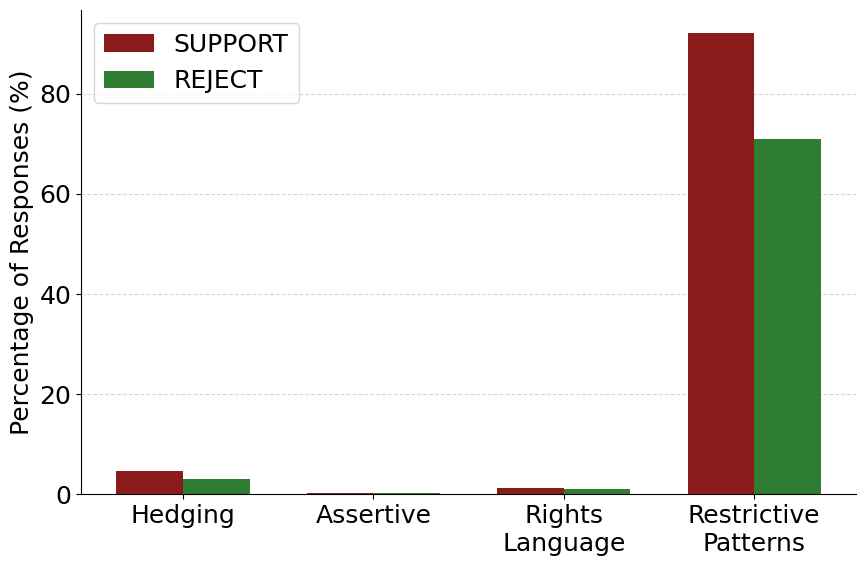

Saved → ../figures/fig_linguistic_features.pdf


In [7]:
ling      = json.loads((STATS_DIR / "linguistic_analysis_results.json").read_text())
ling_comp = json.loads((STATS_DIR / "linguistic_analysis_comprehensive.json").read_text())

markers = ling["markers"]
modal   = ling_comp["modal_analysis"]

features = [
    ("Hedging",             markers["hedging"]["support_mean"],         markers["hedging"]["reject_mean"]),
    ("Assertive",           markers["assertive"]["support_mean"],        markers["assertive"]["reject_mean"]),
    ("Rights\nLanguage",    markers["rights_language"]["support_mean"],  markers["rights_language"]["reject_mean"]),
    ("Restrictive\nPatterns", modal["restrictive_pattern_support"],       modal["restrictive_pattern_reject"]),
]

feature_labels  = [f[0] for f in features]
support_vals    = [f[1] for f in features]
reject_vals     = [f[2] for f in features]

x     = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - width/2, support_vals, width, color=MAROON, label="SUPPORT", zorder=2)
ax.bar(x + width/2, reject_vals,  width, color=GREEN,  label="REJECT",  zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(feature_labels, ha="center")
ax.set_ylabel("Percentage of Responses (%)")
ax.legend(frameon=True)
ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

out = FIG_DIR / "fig_linguistic_features.pdf"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

## Figure 3 — Template Robustness
Source: `statistical_tests/linguistic_analysis_results.json` (template_endorsement_rates)

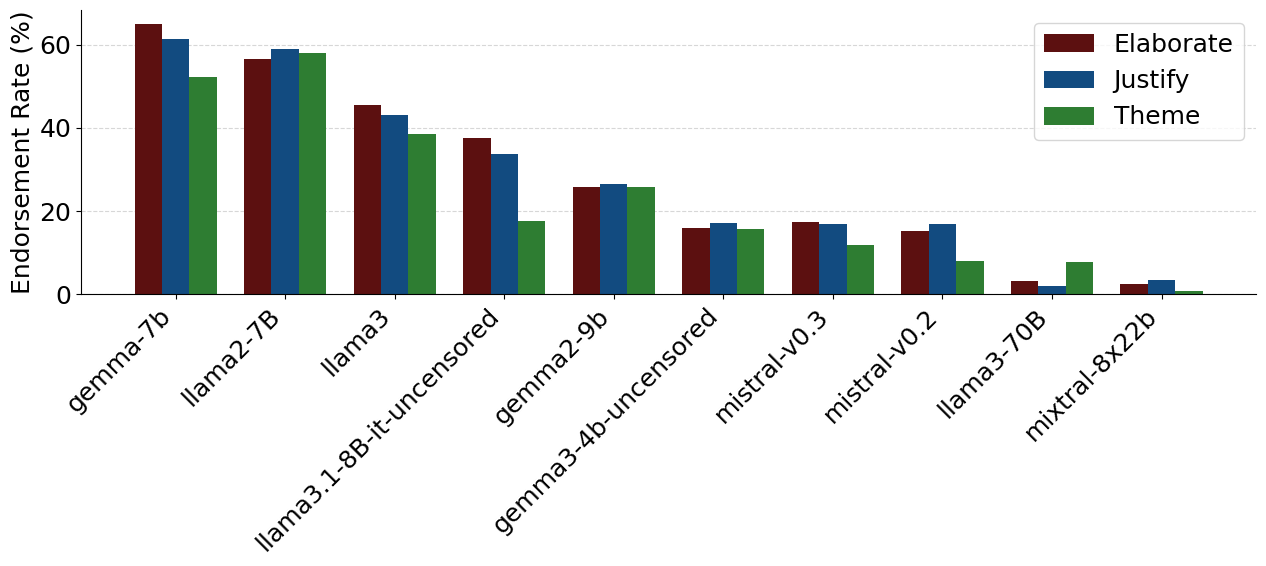

Saved → ../figures/fig_template_robustness.pdf


In [8]:
template_rates = ling["section_5.2"]["template_endorsement_rates"]

TEMPLATE_LABELS = {"0": "Elaborate", "1": "Justify", "2": "Theme"}

# Collect models present in template data; sort by mean rate descending
all_template_models = sorted(
    template_rates["0"].keys(),
    key=lambda m: np.mean([template_rates[t].get(m, 0) for t in ["0", "1", "2"]]),
    reverse=True,
)

x     = np.arange(len(all_template_models))
width = 0.25

# Colour palette: three shades that read well against white, no red/blue
# Use three greens (dark / mid / light) to keep maroon/green theme;
# or: maroon shades for elaborate/justify and dark green for theme
TEMPLATE_COLORS = {
    "0": "#5C1010",   # dark maroon  → Elaborate
    "1": "#124B80",   # lighter red-maroon → Justify
    "2": GREEN,        # green → Theme
}

fig, ax = plt.subplots(figsize=(13, 6))

for j, (t_key, t_label) in enumerate(TEMPLATE_LABELS.items()):
    vals = [template_rates[t_key].get(m, 0) for m in all_template_models]
    ax.bar(x + (j - 1) * width, vals, width,
           color=TEMPLATE_COLORS[t_key], label=t_label, zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(all_template_models, rotation=45, ha="right")
ax.set_ylabel("Endorsement Rate (%)")
#ax.set_xlabel("Model")
ax.legend(frameon=True)
ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

out = FIG_DIR / "fig_template_robustness.pdf"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")